In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
#from scipy.spatial.distance import cdist
#from scipy.stats import mode
from scipy.signal import welch, butter, lfilter
from scipy.fft import fft, fftfreq
import os
import csv
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Exploration (FFT & PSD)

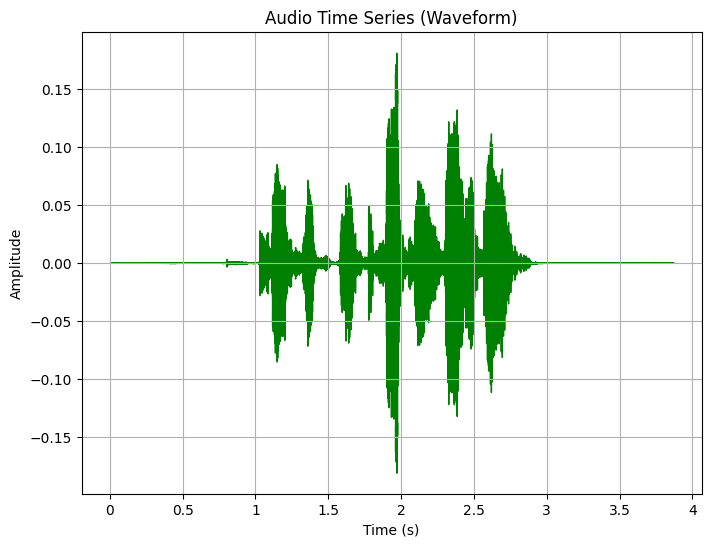

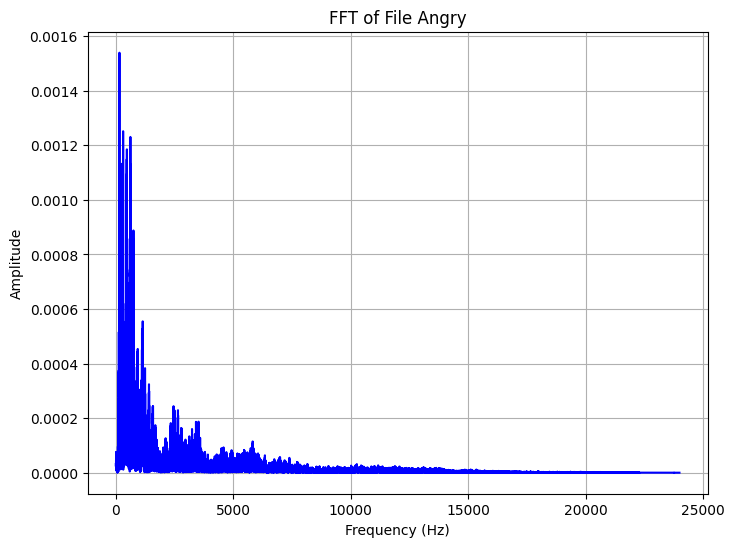

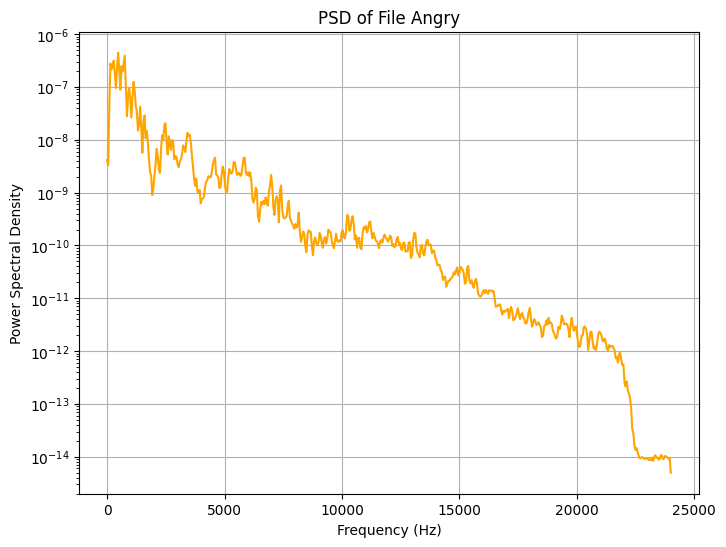

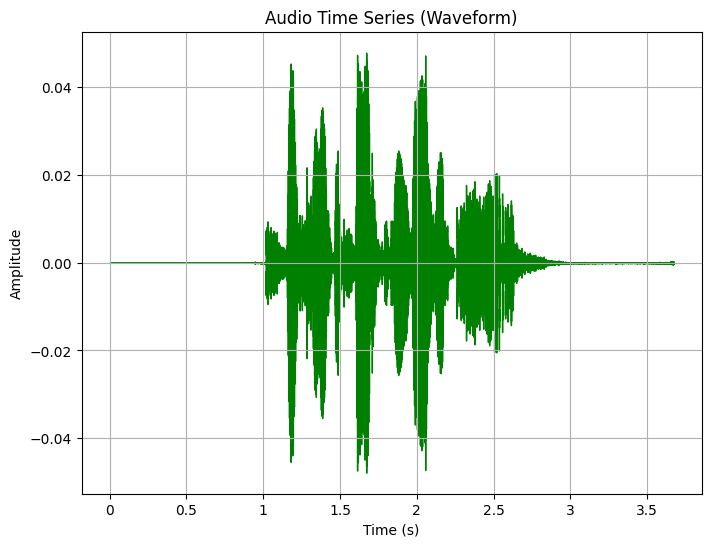

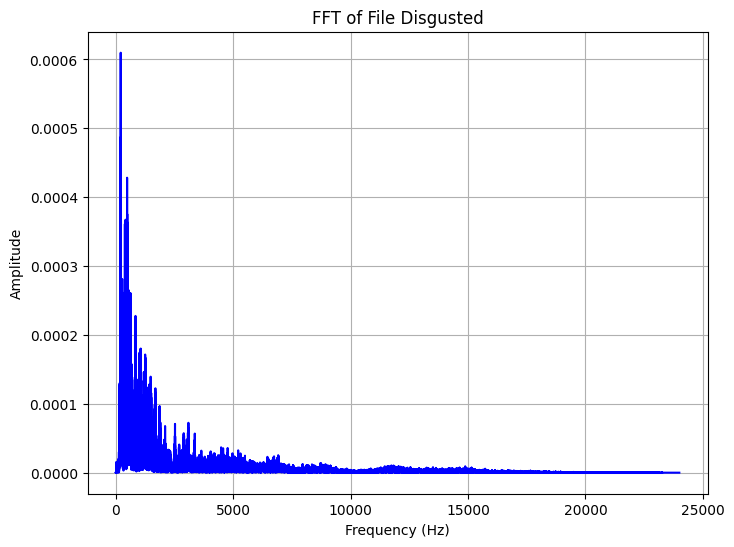

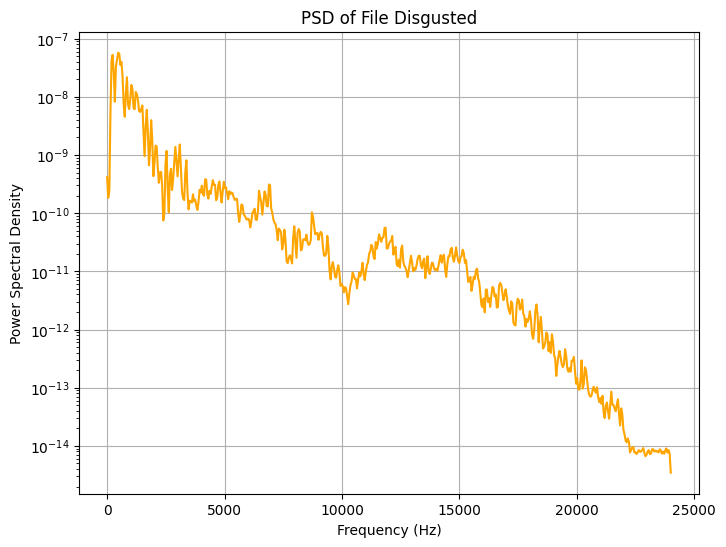

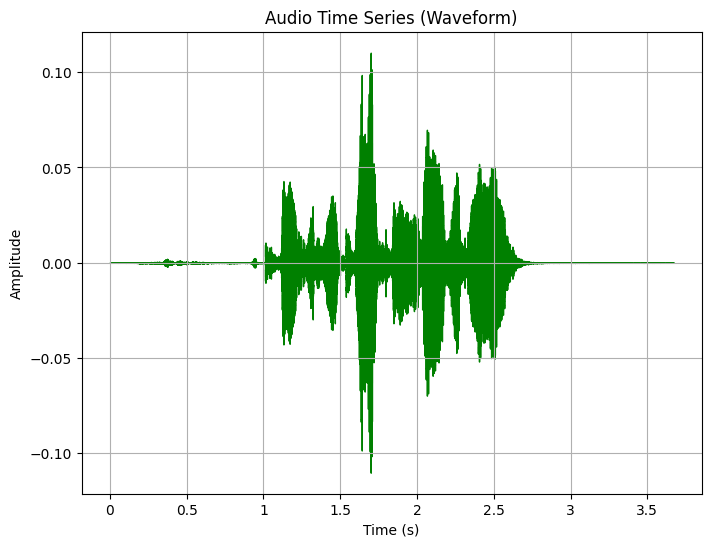

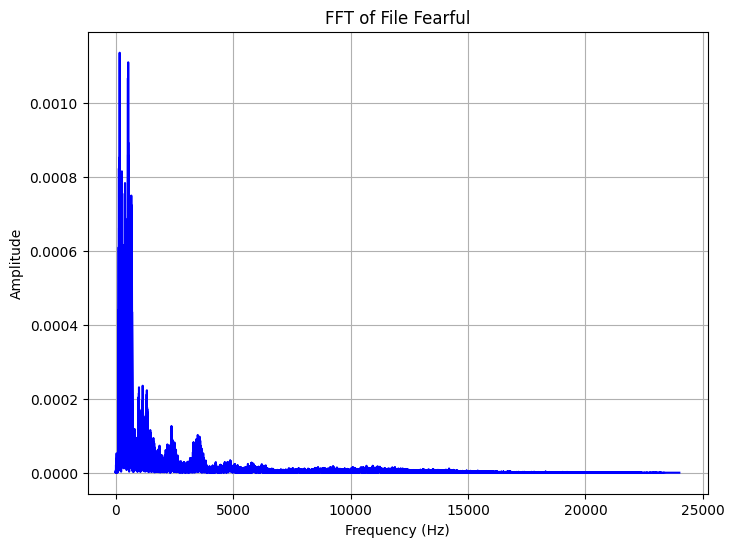

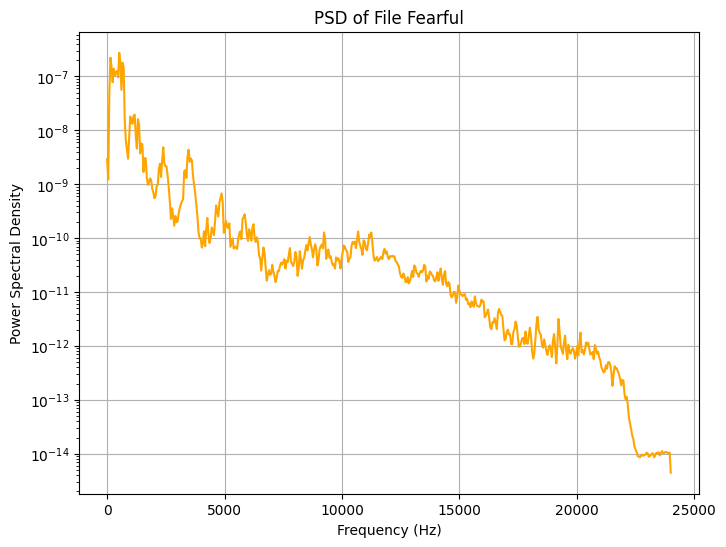

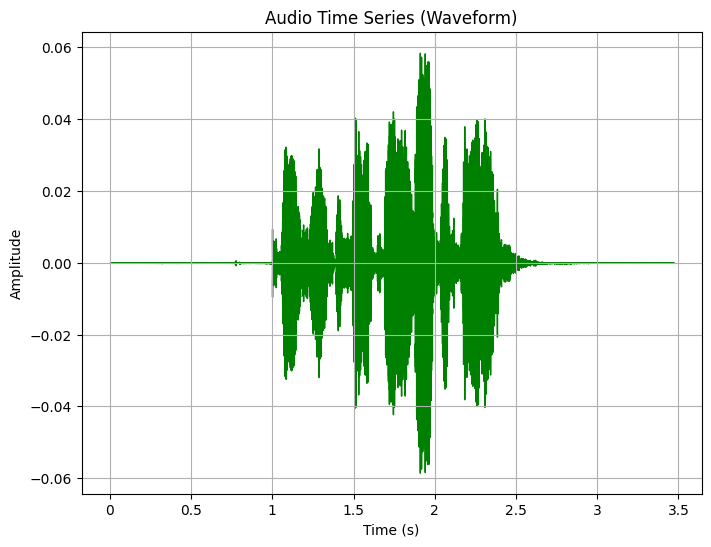

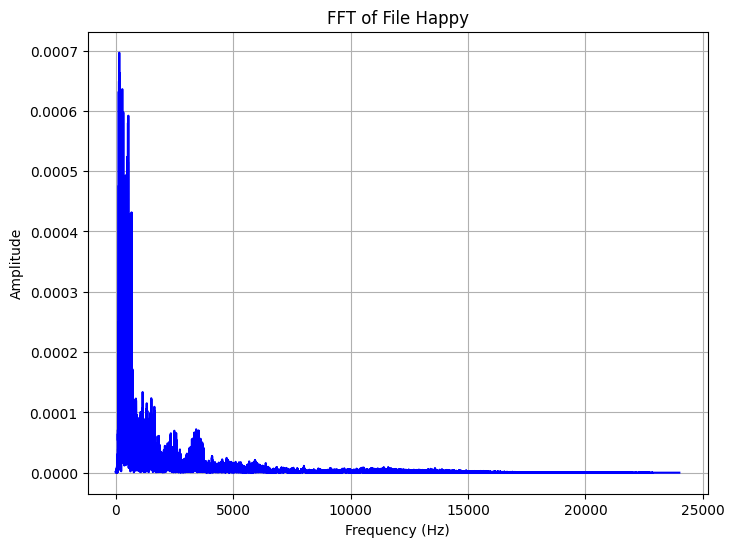

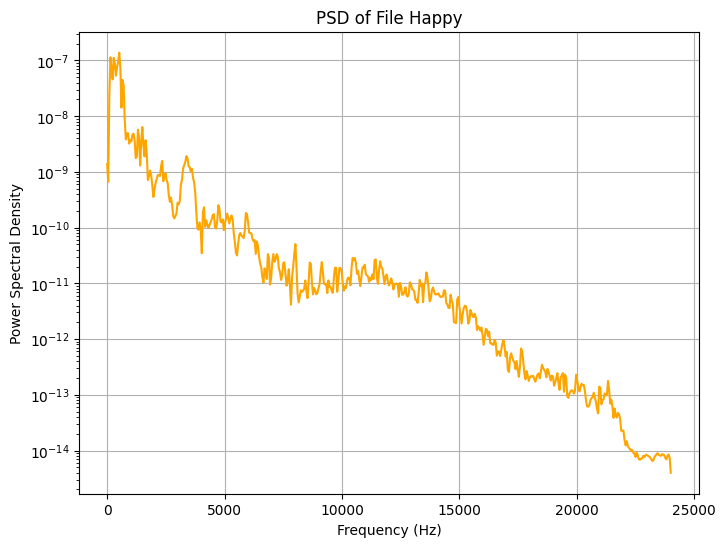

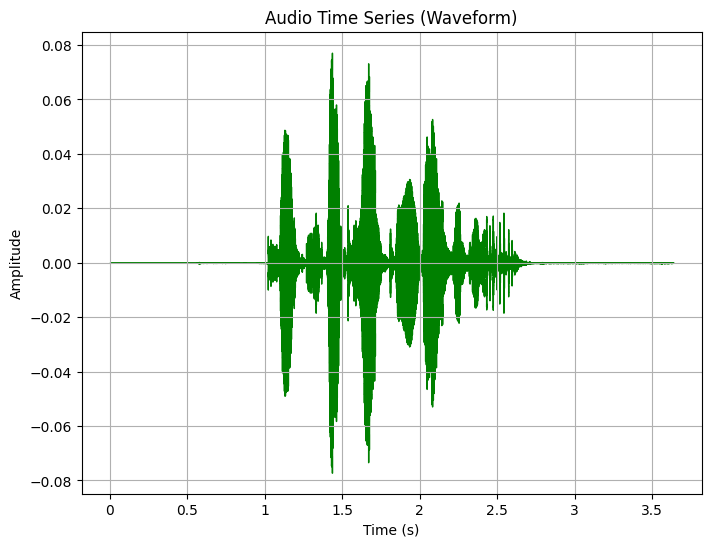

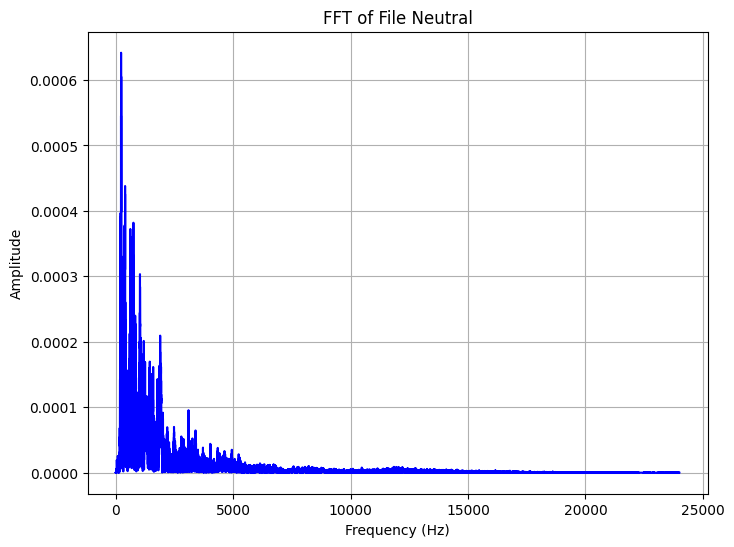

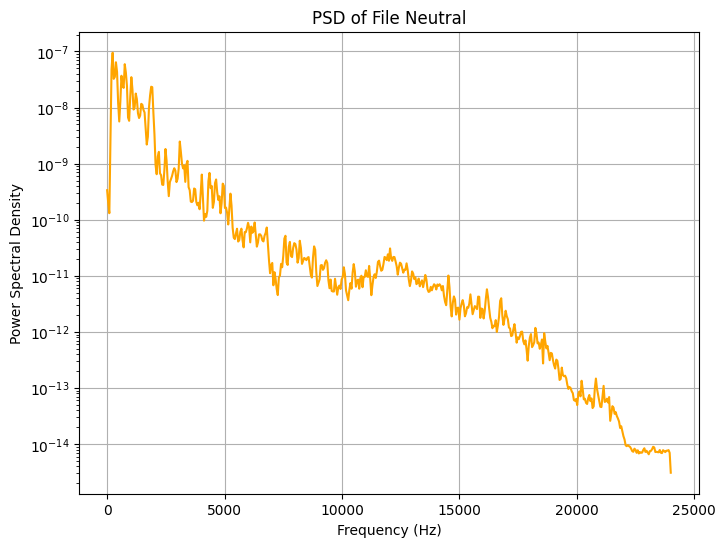

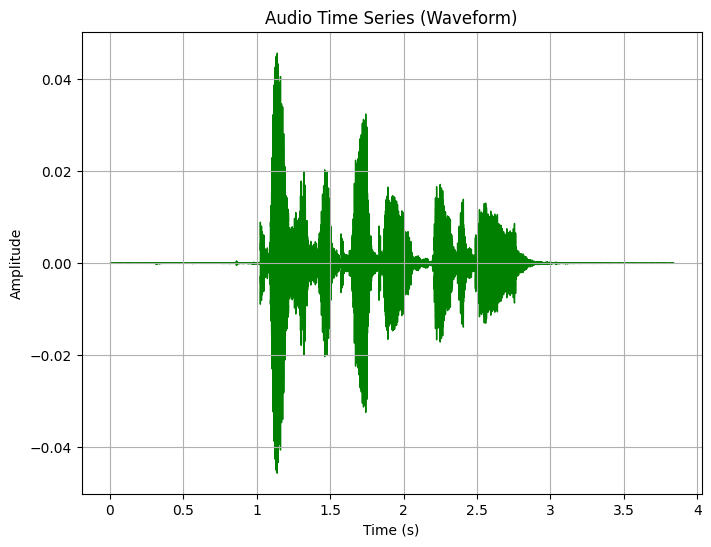

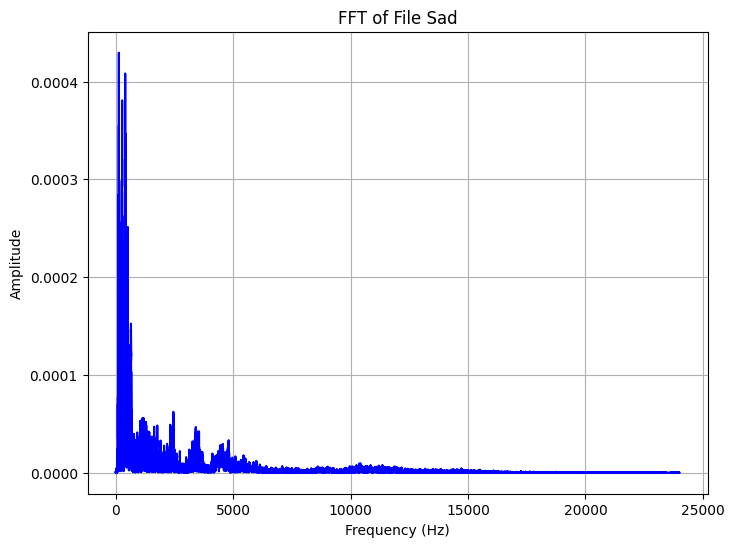

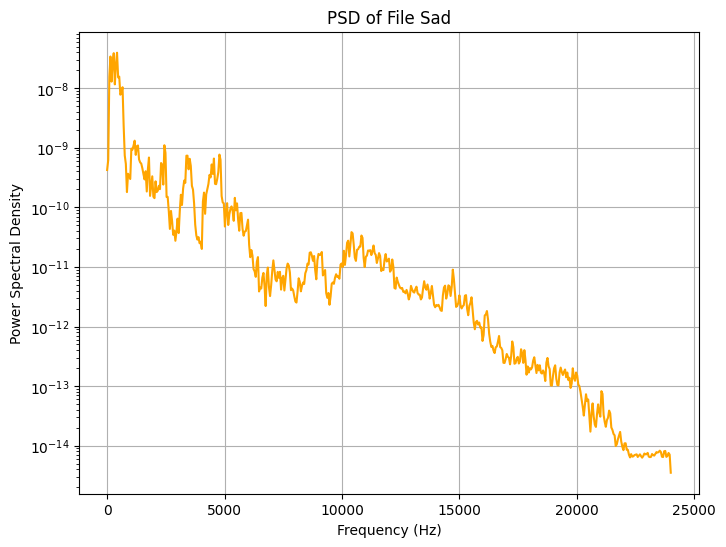

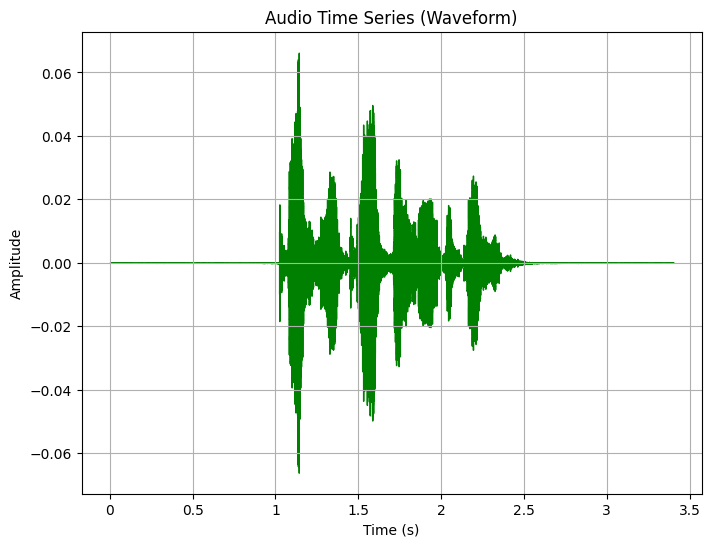

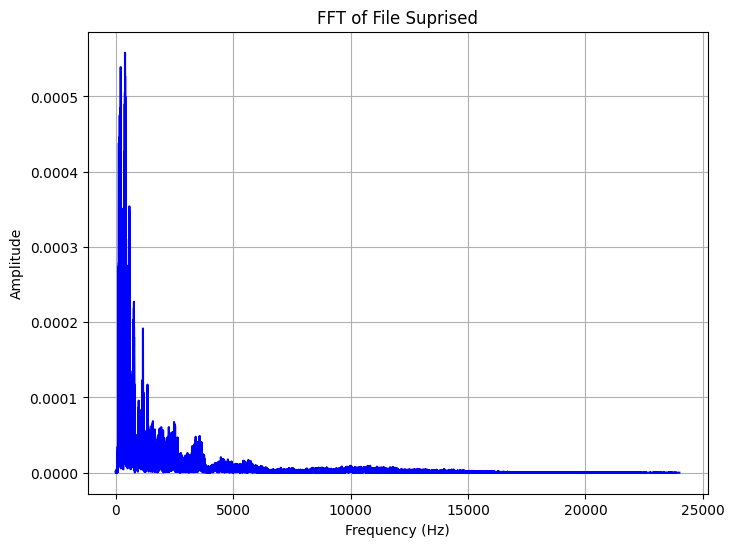

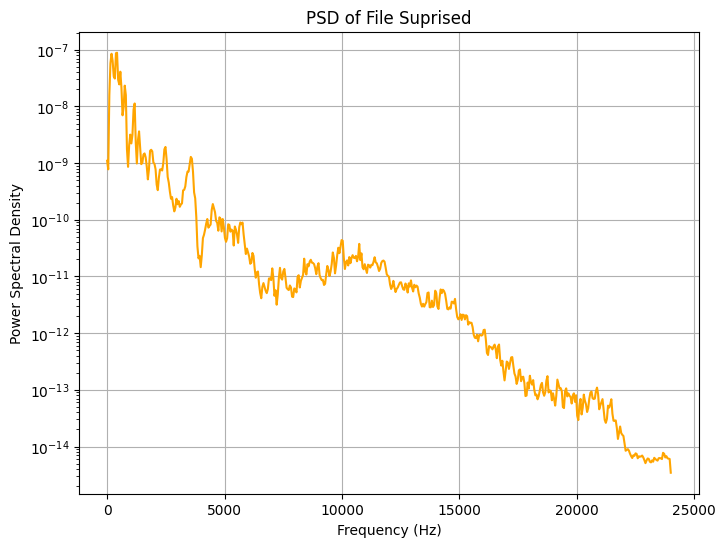

In [ ]:
# Load labels from CSV
emotions = ["Angry","Disgusted","Fearful","Happy","Neutral","Sad","Suprised"]
test = []
labels = []

for i in emotions:
    file_name = f'/content/drive/My Drive/Elec 378/Final Proj/dataset/{i}/{i+"1"}.wav'
    y, sr = librosa.load(file_name, sr=None)  # load full audio signal

    # raw audio waveform
    # Plot the waveform
    plt.figure(figsize=(8, 6))
    librosa.display.waveshow(y, sr=sr, color = 'green')
    plt.title("Audio Time Series (Waveform)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()
    # fft
    N = len(y)
    yf = fft(y)
    xf = fftfreq(N, 1 / sr)[:N // 2]
    plt.figure(figsize=(8, 6))
    plt.plot(xf, 2.0 / N * np.abs(yf[0:N // 2]), color = 'blue')
    plt.title(f"FFT of File {i}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

    # psd
    f, Pxx = welch(y, sr, nperseg=1024)
    plt.figure(figsize=(8, 6))
    plt.semilogy(f, Pxx, color = 'orange')
    plt.title(f"PSD of File {i}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.grid()
    plt.show()

Feature Extraction for SVM (per audio signal)

In [ ]:
# Load labels from CSV
emotions = ["Angry","Disgusted","Fearful","Happy","Neutral","Sad","Suprised"]
test = []
labels = []

def extract_features(file_name):
    try:
        # Load a segment of the audio file
        audio_timeseries, sampling_rate = librosa.load(file_name, sr=None)

        # Butterworth Filter to limit frequency range
        f_nyq = sampling_rate / 2
        f_low = 20/f_nyq
        f_high = min(20000/f_nyq, 0.99)
        b, a = butter(4, [f_low, f_high], btype='band')
        audio_timeseries = lfilter(b, a, audio_timeseries)

        # MFCC features
        mfccs = librosa.feature.mfcc(y=audio_timeseries, sr=sampling_rate, n_mfcc=20)
        deltas = librosa.feature.delta(mfccs)
        deltas2 = librosa.feature.delta(mfccs, order=2)

        # Spectral features
        spectral_contrast = librosa.feature.spectral_contrast(y=audio_timeseries, sr=sampling_rate)
        spectral_centroid = librosa.feature.spectral_centroid(y=audio_timeseries, sr=sampling_rate)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio_timeseries, sr=sampling_rate)
        spectral_flatness = librosa.feature.spectral_flatness(y=audio_timeseries)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_timeseries, sr=sampling_rate)

        chroma = librosa.feature.chroma_stft(y=audio_timeseries, sr=sampling_rate)
        rms = librosa.feature.rms(y=audio_timeseries)
        zcr = librosa.feature.zero_crossing_rate(y=audio_timeseries)

        # pitches, magnitudes = librosa.piptrack(y=audio_timeseries, sr=sampling_rate)

        # Filter valid pitch values
        #pitches = pitches[pitches > 0]
        #pitch_mean = np.mean(pitches) if pitches.size > 0 else 0
        #pitch_std = np.std(pitches) if pitches.size > 0 else 0

        #  append mean and std of features
        feature_vector = np.hstack([
            np.mean(mfccs, axis=1),
            np.mean(rms),
            np.mean(chroma, axis=1),
            np.mean(spectral_contrast, axis=1),
            np.mean(deltas, axis=1),
            np.mean(deltas2, axis=1),
            np.mean(zcr),
            #pitch_mean,
            #pitch_std,
            np.std(mfccs, axis=1),
            np.std(rms),
            np.std(chroma, axis=1),
            np.std(zcr),
            np.mean(spectral_centroid), np.std(spectral_centroid),
            np.mean(spectral_bandwidth), np.std(spectral_bandwidth),
            np.mean(spectral_flatness), np.std(spectral_flatness),
            np.mean(spectral_rolloff), np.std(spectral_rolloff),

            np.min(mfccs, axis=1),
            np.max(mfccs, axis=1),
            np.median(mfccs, axis=1),

        ])

        return feature_vector
    except Exception as e:
        print(f"Error loading {file_name}: {e}")
        return None




## Visualizing Feature Extraction

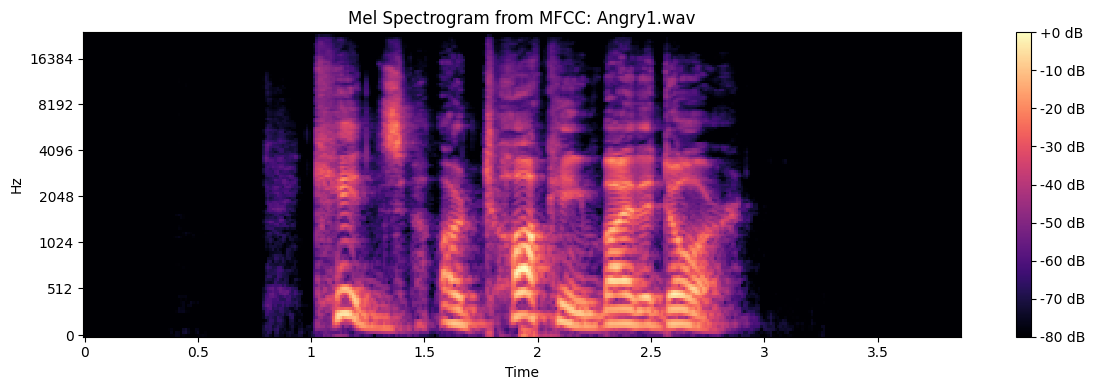

In [ ]:
# Mel Spectrogram from MFCC extraction

def melspec_from_mfcc(file_path):
    # Load audio with same parameters as extract_features
    y, sr = librosa.load(file_path, sr=None)

    # Calculate Mel spectrogram with librosa's default parameters for MFCC
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, hop_length=512)

    log_S = librosa.power_to_db(S, ref=np.max)  # Same dB conversion as MFCC pipeline

    # Create plot with matching parameters
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(log_S, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel Spectrogram from MFCC: {file_path.split("/")[-1]}')
    plt.tight_layout()
    plt.show()

# Visualization for the Angry1 file
file_path = '/content/drive/My Drive/Elec 378/Final Proj/dataset/Angry/Angry1.wav'
melspec_from_mfcc(file_path)

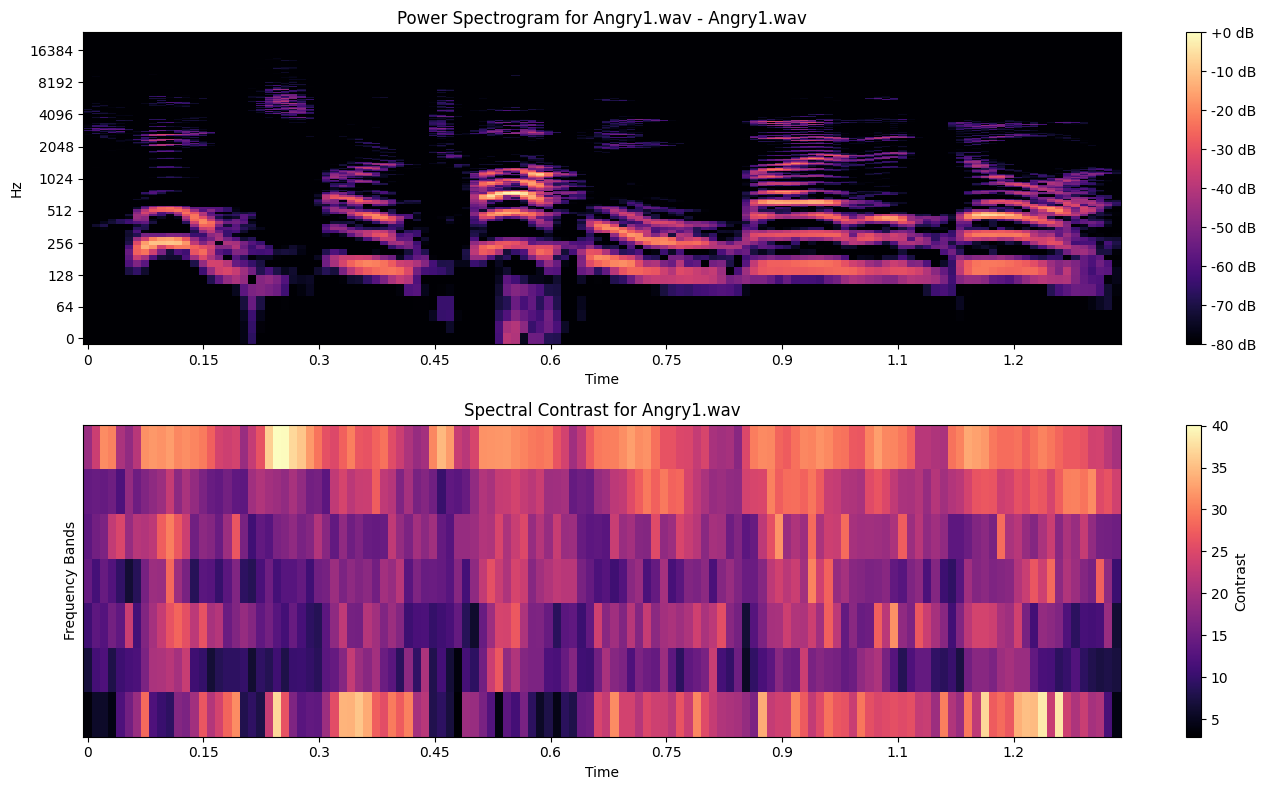

In [ ]:
# Spectrograms for Spectral Contrast for first file

file_path = '/content/drive/My Drive/Elec 378/Final Proj/dataset/Angry/Angry1.wav'

# Load audio w/ silence removed
y, sr = librosa.load(file_path, sr=None)
intervals = librosa.effects.split(y, top_db=20)
y_trimmed = np.concatenate([y[start:end] for start, end in intervals])

# Feature extraction
stft = librosa.stft(y_trimmed)
power_spectrogram = np.abs(stft)**2
log_power = librosa.amplitude_to_db(power_spectrogram, ref=np.max)
spectral_contrast = librosa.feature.spectral_contrast(y=y_trimmed, sr=sr)


#plots
plt.figure(figsize=(14, 8))

# power spectrogram
plt.subplot(2, 1, 1)
librosa.display.specshow(log_power, sr=sr, hop_length=512, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Power Spectrogram for Angry1.wav - {file_path.split("/")[-1]}')

# spectral contrast
plt.subplot(2, 1, 2)
librosa.display.specshow(spectral_contrast, sr=sr, hop_length=512, x_axis='time')
plt.colorbar(label='Contrast')
plt.title('Spectral Contrast for Angry1.wav')
plt.ylabel('Frequency Bands')

plt.tight_layout()
plt.show()

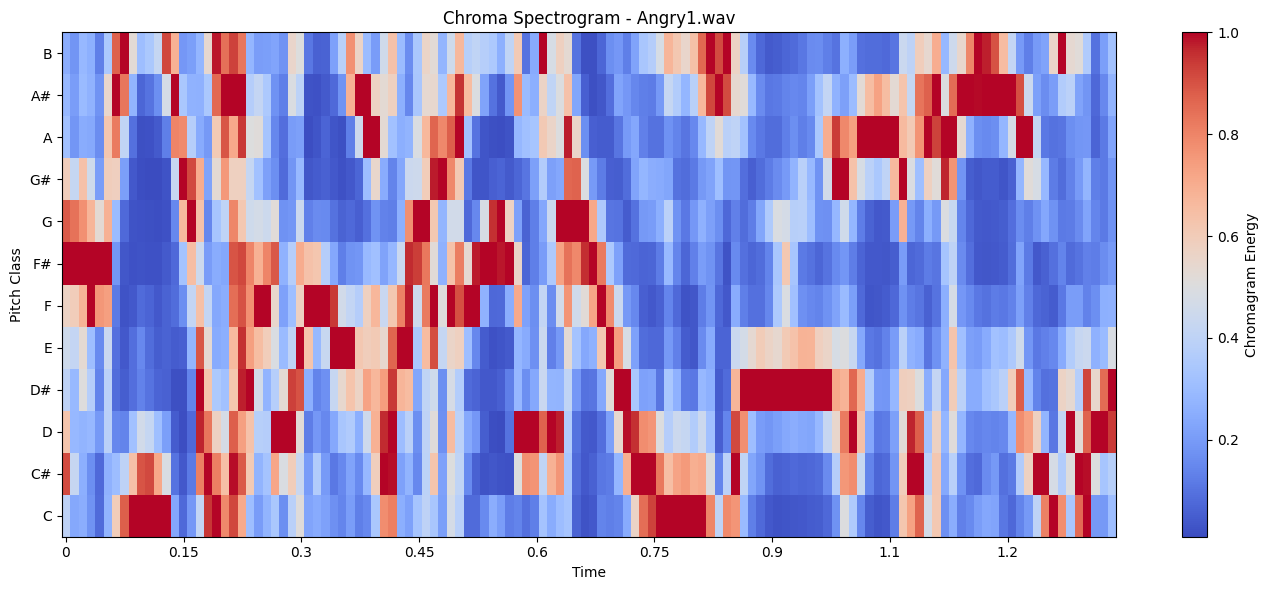

In [ ]:
# chroma spectrogram

file_path = '/content/drive/My Drive/Elec 378/Final Proj/dataset/Angry/Angry1.wav'

y, sr = librosa.load(file_path, sr=None)
intervals = librosa.effects.split(y, top_db=20)
y_trimmed = np.concatenate([y[start:end] for start, end in intervals])

chroma = librosa.feature.chroma_stft(y=y_trimmed, sr=sr)

plt.figure(figsize=(14, 6))
librosa.display.specshow(chroma, sr=sr, hop_length=512, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar(label='Chromagram Energy')
plt.title(f'Chroma Spectrogram - {file_path.split("/")[-1]}')
#  musical notes?
plt.yticks(ticks=np.arange(12),
          labels=['C', 'C#', 'D', 'D#', 'E', 'F',
                  'F#', 'G', 'G#', 'A', 'A#', 'B'])
plt.ylabel('Pitch Class')
plt.tight_layout()
plt.show()


Loading Dataset and Running Feature Extraction

In [ ]:
# Load dataset and extract features

[ ]

features = []
labels_for_features = []

for i in emotions:
    file_path = f'/content/drive/My Drive/Elec 378/Final Proj/dataset/{i}/'
    for filename in os.listdir(file_path):
      #if filename.endswith(".wav") and filename.startswith(i):
      file_name = os.path.join(file_path, filename)
      extracted_features = extract_features(file_name)
      if extracted_features is not None:
          features.append(extracted_features)
          # Each segment gets the same label which is why we need to get the labels first
          labels_for_features.append(i)


# SVM

SVM Model Initialization and Cross Validation for Average Accuracy

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels_encoded = le.fit_transform(labels_for_features)

features_np = np.array(features)

clf = RandomForestClassifier(n_estimators=100, random_state=42)

n_features_to_select = features_np.shape[1] - 83
rfe = RFE(estimator=clf, n_features_to_select=n_features_to_select, step=5)

rfe.fit(features_np, labels_encoded)
features_reduced = rfe.transform(features_np)
selected_indices = np.where(rfe.support_)[0]
ranking = rfe.ranking_


import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# Assuming features_reduced and labels_for_features are already populated
# If features_reduced is not defined, you can replace it with the desired reduced features set

features_reduced = np.array(features_reduced)  # Convert to numpy array if it's a list

# Initialize cross-validation
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
accuracies = []

# Initialize SVM model and preprocessing
svm_clf = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
scaler = StandardScaler()
pca = PCA(n_components=.998)  # Keep 99.8% of the variance

# Cross-validation loop
for train_index, test_index in kf.split(features_reduced, labels_encoded):
    X_train, X_test = features_reduced[train_index], features_reduced[test_index]
    y_train, y_test = labels_encoded[train_index], labels_encoded[test_index]

    # scale data
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # PCA
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # fit the model and predict
    svm_clf.fit(X_train_pca, y_train)
    y_pred = svm_clf.predict(X_test_pca)

    # calc accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# calc avg accuraacy
average_accuracy = np.mean(accuracies)
print(f"Average Accuracy: {average_accuracy * 100:.2f}%")


Call SVM on Test data

In [ ]:
# Load test data
test_features = []

folder_path = f'/content/drive/My Drive/Elec 378/Final Proj/dataset/Test/'
test_num = 1
while os.path.exists(f'{folder_path}{test_num}.wav'):
  file_path = f'{folder_path}{test_num}.wav'
  features = extract_features(file_path)
  if features is not None:
    test_features.append(features)
  test_num += 1




In [ ]:
# Call SVM and write to CSV
# Convert list of arrays into a single numpy array

test_features = np.array(test_features)

test_scaled = scaler.transform(test_features)
test_pca = pca.transform(test_scaled)

# Predict using the SVM (with decoded predictions)
test_pred = svm_clf.predict(test_pca)
test_pred_labels = label_encoder.inverse_transform(test_pred)


# Save to a CSV for submission to Kaggle
with open('svm.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['filename', 'emotion'])
    for i, emotion in enumerate(test_pred_labels, start=1):
        writer.writerow([f'{i}.wav', emotion])

# SVM Hyperparameter Tuning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

features_reduced = np.array(features_reduced)
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_for_features)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.998)),
    ('svm', SVC(class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svm__gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
grid_search.fit(features_reduced, labels_encoded)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_ * 100:.2f}%")

results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(14, 6))
sns.set(style="whitegrid")

print(results[['param_svm__C', 'param_svm__kernel', 'param_svm__gamma', 'mean_test_score']])

sns.barplot(
    data=results,
    x='param_svm__C',
    y='mean_test_score',
    hue='param_svm__kernel',
    ci=None,
    palette='tab10'
)

plt.title('SVM Hyperparameter Tuning')
plt.xlabel('C')
plt.ylabel('Avg Accuracy')
plt.ylim(0, 1)
plt.legend(title='Kernel')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# encode labels to idx
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_for_features)

features_reduced = np.array(features_reduced)

# Kfold cross-validation
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# SVVM
svm_clf = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
scaler = StandardScaler()

pca_levels = [1.0, 0.998, 0.98, 0.95, 0.90]
accuracy_results = []

for pca_level in pca_levels:
    accuracies = []
    apply_pca = pca_level < 1.0
    if apply_pca:
        pca = PCA(n_components=pca_level)

    for train_index, test_index in kf.split(features_reduced, labels_encoded):
        X_train, X_test = features_reduced[train_index], features_reduced[test_index]
        y_train, y_test = labels_encoded[train_index], labels_encoded[test_index]

        # scale data
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # PCA
        if apply_pca:
            X_train_scaled = pca.fit_transform(X_train_scaled)
            X_test_scaled = pca.transform(X_test_scaled)

        svm_clf.fit(X_train_scaled, y_train)
        y_pred = svm_clf.predict(X_test_scaled)

        # calc accuracy
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)

    avg_acc = np.mean(accuracies)
    accuracy_results.append(avg_acc)
    print(f"PCA {pca_level}: Average Accuracy = {avg_acc * 100:.2f}%")

#plot
plt.figure(figsize=(8, 6))
plt.bar([str(l) for l in pca_levels], [acc * 100 for acc in accuracy_results], color='skyblue')
plt.xlabel('Variance Captured by PCA')
plt.ylabel('Avg Accuracy (%)')
plt.title('SVM Accuracy for Different PCA Levels')
plt.ylim(0, 100)
plt.show()


# CNN

Generate Mel Spectrograms

In [ ]:
def gen_melspec(file_name, n_mels):
  #load audio
  audio_timeseries, sampling_rate = librosa.load(file_name)
  #removes silent parts of interval
  intervals = librosa.effects.split(audio_timeseries, top_db=20)
  concat_audio = []
  for start, end in intervals:
    concat_audio.append(audio_timeseries[start:end])
  shortened_audio = np.concatenate(concat_audio)
  #generates melspec
  mel_spec = librosa.feature.melspectrogram(y=shortened_audio, sr=sampling_rate, n_mels=n_mels)
  log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
  return log_mel_spec, sampling_rate

def resize_melspec(spec):
    spec = spec.unsqueeze(0).unsqueeze(0)
    pooled = F.adaptive_avg_pool2d(spec, (spec.shape[2], 64))
    return pooled.squeeze(0)


Load Data and Convert to Tensors for CNN

In [ ]:
melspec_data = []
labels = []
emotions = ["Angry","Disgusted","Fearful","Happy","Neutral","Sad","Suprised"]
emotions_dict = {0:'Angry', 1:'Disgusted',2: 'Fearful',3: 'Happy',4: 'Neutral',5: 'Sad',6: 'Suprised'}
for i in range(len(emotions)):
  file_path = f'/content/drive/My Drive/Elec 378/Final Proj/dataset/{emotions[i]}/'
  for filename in os.listdir(file_path):
    file_name = os.path.join(file_path, filename)
    #generate melspec for each datapoint
    melspec, sr = gen_melspec(file_name, 64)
    #convert to tensors for CNN
    melspec_tensor = torch.tensor(melspec, dtype=torch.float32)
    #resize time dim to 64 to keep size consistent using avg pool
    melspec_tensor = resize_melspec(melspec_tensor)
    melspec_data.append(melspec_tensor)
    labels.append(i)
#convert to tensors for CNN
melspec_data = torch.stack(melspec_data)
labels = torch.tensor(labels, dtype=torch.long)
print(melspec_data.shape)
print(labels.shape)

In [ ]:
#CNN Model


# convert to tensors
dataset = TensorDataset(melspec_data, labels)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# Define the CNN (same as before)
cnn = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding = 1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2),

    nn.Conv2d(32,32, kernel_size=3, stride=1, padding = 1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2),

    nn.Conv2d(32,16, kernel_size=3, stride=1, padding = 1),
    nn.ReLU(),
    nn.BatchNorm2d(16),
    nn.MaxPool2d(2),

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),

    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(16, 7)

)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.003)
epoch_accuracies = []

# Training loop
for epoch in range(50):
  cnn.train()
  total_loss = 0.0
  for inputs, targets in loader:
      outputs = cnn(inputs)
      loss = criterion(outputs, targets)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

  avg_loss = total_loss / len(loader)

  correct_predictions = 0
  total_samples = 0
  for inputs, targets in loader:
      outputs = cnn(inputs)
      _, predicted = torch.max(outputs, 1)
      total_samples += targets.size(0)
      correct_predictions += (predicted == targets).sum().item()

  accuracy = correct_predictions / total_samples
  epoch_accuracies.append(accuracy)

  print(f"Epoch {epoch+1} loss: {avg_loss:.4f}, accuracy: {accuracy:.4f}")



In [ ]:
test_melspecs = []
filenames = []

folder_path = '/content/drive/My Drive/Elec 378/Final Proj/dataset/Test/'
test_num = 1

while os.path.exists(f'{folder_path}{test_num}.wav'):
    file_path = f'{folder_path}{test_num}.wav'

    # Generate mel spectrogram and resize
    melspec,sr = gen_melspec(file_path, 64)

    melspec_tensor = torch.tensor(melspec, dtype=torch.float32)
    #resize time dim to 64 to keep size consistent using avg pool
    melspec_tensor = resize_melspec(melspec_tensor)

    test_melspecs.append(melspec_tensor)
    filenames.append(f'{test_num}.wav')

    test_num += 1

test_melspec_batch = torch.stack(test_melspecs)

#predictions
cnn.eval()
with torch.no_grad():
    outputs = cnn(test_melspec_batch)
    #one hot encoding
    predictions = torch.max(outputs, 1)[1]

# map predicted class indices to emotion
predicted_labels = [emotions_dict[idx.item()] for idx in predictions]

# Write to CSV
with open('cnn.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['filename', 'emotion'])
    for filename, emotion in zip(filenames, predicted_labels):
        writer.writerow([filename, emotion])


In [ ]:
CNN Epoch Graph

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), epoch_accuracies, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.grid(True)
plt.tight_layout()
plt.show()
